# Demand Estimation and Market Analysis: Air Fryers

In this lab, you will study the market for air fryers using brand-year data aggregated from Amazon purchases. The goal is to move from descriptive analysis to a simple demand model, and then use that model to infer markups and unit costs.

Use the cleaned file:

```python
air_fryers_clean_brand_year.csv
```

This file keeps the top 10 air-fryer brands from 2019-2023 and drops the long tail of very small brands. The variable `brand_share` has already been recomputed within this cleaned name-brand market, so shares sum to 1 within each year.

Use `pandas`, `numpy`, `seaborn`, `matplotlib`, and `scikit-learn`. Do **not** use scikit-learn pipelines for this assignment. Use ordinary data frames, `pd.get_dummies`, and `LinearRegression` so that every column in the model is visible and interpretable.

## Load Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
from sklearn.linear_model import LinearRegression, LassoCV, lasso_path, Lasso
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score

## Data

Each row is one brand in one year.

Important columns:

- `year`: calendar year
- `brand`: air-fryer brand
- `purchase_count`: number of purchases by that brand in that year
- `product_count`: number of distinct products observed for that brand-year
- `avg_price`: average price for that brand-year
- `avg_rating`: average review rating for that brand-year
- `brand_share`: purchase share within the cleaned air-fryer market in that year
- `log_brand_share`: `np.log(brand_share)`, already computed for convenience
- `compact_share`, `dual_basket_share`, `oven_style_share`, `rotisserie_share`, `window_share`: product characteristic shares for the brand-year

The original lecture wrote the demand equation using an outside option:

$$
\log(s_{bt}) - \log(s_{ot}).
$$

For this cleaned dataset, we dropped the nuisance long-tail brands instead of treating them as an outside option. You should therefore use:

$$
y_{bt} = \log(s_{bt})
$$

as the outcome and include **year dummies**. The year dummies absorb the year-specific denominator of the multinomial logit share equation. This keeps the assignment focused on the cleaned name-brand market.

## 1. Data Analysis

Load `air_fryers_clean_brand_year.csv`.

In [4]:
df = pd.read_csv('data/air_fryers_clean_brand_year.csv')
df.head()

,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364


### 1. Verify that the data contain 10 brands and the years 2019-2023.

In [5]:
print('Number of brands: ', df['brand'].nunique())
print('Year range: ', df['year'].unique())

Number of brands:  10
Year range:  [2019 2020 2021 2022 2023]


### 2. Check that `brand_share` sums to 1 within each year.

In [6]:
print(df.groupby('year')['brand_share'].sum())

year
2019    1.0
2020    1.0
2021    1.0
2022    1.0
2023    1.0
Name: brand_share, dtype: float64


### 3. Plot the following over time by brand:
   - average price
   - average rating
   - brand market share

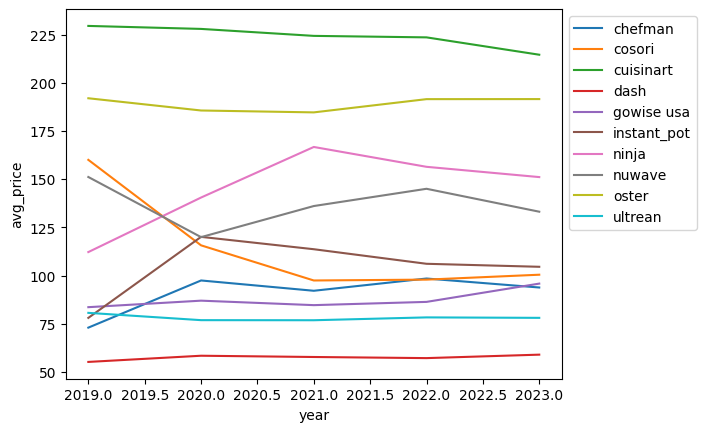

In [7]:
sns.lineplot(x=df['year'],y=df['avg_price'], hue=df['brand'])
plt.legend(bbox_to_anchor=(1.0, 1), loc='upper left')
plt.show()

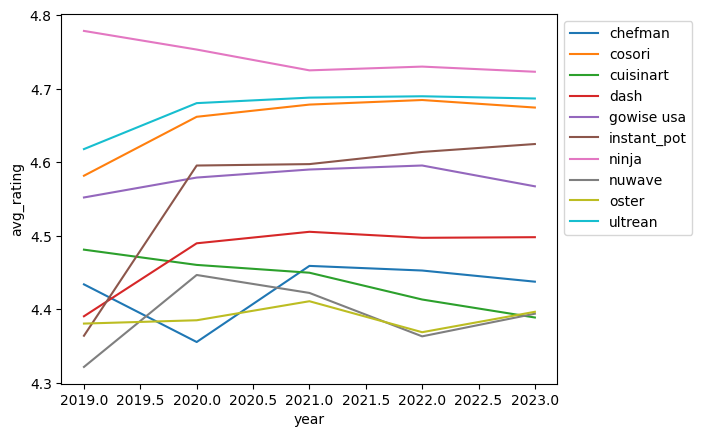

In [8]:
sns.lineplot(x=df['year'],y=df['avg_rating'], hue=df['brand'])
plt.legend(bbox_to_anchor=(1.0, 1), loc='upper left')
plt.show()

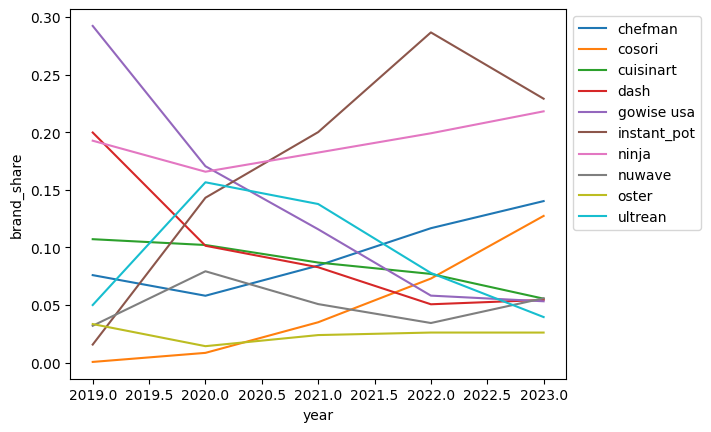

In [9]:
sns.lineplot(x=df['year'],y=df['brand_share'], hue=df['brand'])
plt.legend(bbox_to_anchor=(1.0, 1), loc='upper left')
plt.show()

### 4. Summarize the product characteristics:

In [10]:
characteristics = ['compact_share','dual_basket_share','oven_style_share','rotisserie_share','window_share','brand_share','log_brand_share']

df.groupby('brand')[characteristics].mean()

,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,brand_share,log_brand_share
brand,,,,,,,
chefman,0.961595,0.013462,0.596962,0.370490,0.363081,0.095079,-2.401547
cosori,0.996784,0.000000,0.029952,0.024076,0.000000,0.048974,-4.001337
cuisinart,0.995902,0.000000,0.913059,0.000000,0.000000,0.085787,-2.481962
dash,0.999481,0.000000,0.890098,0.000000,0.000000,0.097862,-2.455952
gowise usa,0.999877,0.000000,0.183790,0.183569,0.001320,0.138005,-2.185988
instant_pot,0.859655,0.000030,0.674784,0.102362,0.003012,0.174921,-2.085045
ninja,0.992084,0.002488,0.100477,0.000000,0.000000,0.191567,-1.656666
nuwave,0.995431,0.006622,0.542646,0.027123,0.000000,0.050559,-3.040212
oster,1.000000,0.000000,0.864518,0.000000,0.000000,0.024876,-3.729607


- **Which features are common?**
   
The most common features are compact and oven-style, with the majority of all products from any brand being compact and at least some of each brand being oven-style. 

- **Which features are rare?**
  
The least common features are dual basket, rotisserie (although this one is more common than the others), and window, with most brands not carrying products with these features.

- **Are there brands that seem to specialize in different product types?**

Yes. For example, cuisinart and dash seem to specialize in oven-style products since the respective shares of their products with this feature are 0.91 and 0.89 (with oster and ultrean also having the greater part of their products with this feature, with 0.86 and 0.83 proportions of their shares respectively). For all brands, most of their shares with the compact feature are greater that 0.95, so all brands seem to specialize in products with this feature.  

### 5. Write a short paragraph describing the market. Which brands are expensive? Which brands have large shares? Does the market look stable over time?


The air fryer market shows clear differences in pricing, market share, and brand performance over time. Cuisinart is the most expensive brand, followed by Oster and Ninja. In terms of market share, Instant Pot currently holds the largest share, although it has been declining in recent years, with Ninja emerging as a strong and growing competitor. Other brands such as Chefman and Cosori are also experiencing upward trends in market share, while brands like Gowise USA have seen significant declines since 2019. Prices and ratings appear relatively stable across most brands, with only a few exceptions such as Ninja and Nuwave increasing in price and Instant Pot experiencing a notable rise in ratings after 2020. However, market share is less stable, with several brands showing noticeable fluctuations over time. Overall, the market appears competitive, with shifting leadership among brands rather than a single dominant player.

## 2. Demand Estimation

We will estimate a logit-style demand model using linear regression. The model is:

$$
\log(s_{bt}) = \alpha_0 + \alpha_t + \gamma_b + \beta_{price}p_{bt} + \beta_{rating}r_{bt} + \sum_{\ell=1}^L \beta_\ell x_{bt\ell} + \epsilon_{bt}.
$$

Here:

- $b$ indexes brands
- $t$ indexes years
- $s_{bt}$ is `brand_share`
- $p_{bt}$ is `avg_price`
- $r_{bt}$ is `avg_rating`
- $x_{bt\ell}$ are the product characteristics
- $\alpha_t$ are year dummy coefficients
- $\gamma_b$ are brand dummy coefficients
- $\beta_{price}$ is **one constant price coefficient**, shared by all brands and all years

That last point matters: do **not** estimate a different price coefficient for every brand-year. We do not have enough information for that, and it would make the cost calculation impossible to interpret.

Use `pd.get_dummies(..., drop_first=True)` for brand and year dummies. The dropped brand and dropped year become the reference categories, so all dummy coefficients are interpreted relative to those omitted categories.

In [11]:
y = df["log_brand_share"]

brand_dummies = pd.get_dummies(df["brand"], 
                               prefix="brand", drop_first=True, dtype=int)
year_dummies = pd.get_dummies(df["year"].astype(str), 
                              prefix="year", drop_first=True, dtype=int)

X = pd.concat(
    [df[["avg_price", "avg_rating",'compact_share','dual_basket_share','oven_style_share','rotisserie_share','window_share']],
    brand_dummies,
    year_dummies],
    axis=1,)

model = LinearRegression()
model.fit(X, y)

predicted_log_share = model.predict(X)
r2 = r2_score(y, predicted_log_share)

coef_table = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_})

print("R-squared:", r2)
coef_table

R-squared: 0.7634539500914361


,feature,coefficient
0,avg_price,-0.037668
1,avg_rating,0.287517
2,compact_share,9.815304
3,dual_basket_share,-9.509686
4,oven_style_share,1.941774
5,rotisserie_share,-5.674054
6,window_share,12.880298
7,brand_cosori,2.551946
8,brand_cuisinart,6.422436
9,brand_dash,0.176655


### Questions:

1. **What is the estimated price coefficient, $\hat{\beta}_{price}$?**

The estimated coefficient for `avg_price` is -0.037668.

2. **Is it negative? Why is that important?**

It is negative, which is important because it aligns with the Law of Demand. As the price increases, the log brand share decreases - so, as the price increases, the amount bought (the demand/market share) decreases.

3. **Which product features are associated with higher demand?**

The product features with positive coefficients (higher demand) are `compact_share`, `oven_style_share`, and `window_share`. 

4. **Which brand dummy coefficients are largest? Remember that these are interpreted relative to the dropped brand.**

The brand dummy coefficients (relative to the chefman brand - which all other brands seem to have positive coefficients in comparison to) with the largest dummy coefficients are cuisinart, ninja, and instant pot.

5. **Which year dummy coefficients are largest? Remember that these are interpreted relative to the dropped year.**

The year dummy coefficients (relative to 2019) with the largest coefficients are 2020 and 2021. 

6. **What is the model's $R^2$?**

R-squared: 0.763

This part of the work is the **data scientist** role: turning the cleaned data into a model that can be used for prediction and interpretation.

## 3. Strategy: Costs, Markups, and Profit

Now use the demand estimate to infer market fundamentals.

The price coefficient is constant across brands and years, $\hat{\beta}_{price}$.

For each brand-year, compute the slope of demand with respect to price as:

$$
\hat{s}'_{bt}(p_{bt}) = \hat{\beta}_{price} s_{bt}(1 - s_{bt}).
$$

Then estimate unit cost, or marginal cost, using the firm's first-order pricing condition:

$$
\hat{c}_{bt} = p_{bt} + \frac{s_{bt}}{\hat{s}'_{bt}(p_{bt})}.
$$

Because $\hat{\beta}_{price}$ should be negative, $\hat{s}'_{bt}(p_{bt})$ should also be negative. If your price coefficient is positive, stop and debug your model before interpreting costs.

Compute:

- `demand_slope`: $\hat{s}'_{bt}(p_{bt})$
- `unit_cost`: $\hat{c}_{bt}$
- `markup`: $m_{bt} = p_{bt} - \hat{c}_{bt}$
- `average_profit`: $s_{bt} \times m_{bt}$

Here `average_profit` is a share-weighted profit index, not total dollars of profit. It is useful for comparing brand-years inside this cleaned market.

In [ ]:
# get the estimated price coef (how does price affect demand)
price_coef = coef_table.loc[
    coef_table["feature"] == "avg_price", 
    "coefficient"
].iloc[0]

print("Estimated price coefficient:", price_coef)


Estimated price coefficient: -0.03766765298429363


- negative, so a higher price leads to lower demand (since so small people don't care about price much)

In [ ]:
# copy of df into results
results = df.copy()

# add predicted log share to results
results["predicted_log_share"] = predicted_log_share

# compute demand slope (how sensitive demand is to price for each year)
results["demand_slope"] = (
    price_coef * results["brand_share"] * (1 - results["brand_share"])
)

# unit cost = price + (share / slope)
results["unit_cost"] = (
    results["avg_price"] + results["brand_share"] / results["demand_slope"]
)

# markup = price - cost (how much the price is above the cost)
results["markup"] = results["avg_price"] - results["unit_cost"]

# share-weighted profit 
results["average_profit"] = results["brand_share"] * results["markup"]

# check (should be close to 0)
results["profit_derivative"] = (
    results["demand_slope"] * results["markup"] + results["brand_share"]
)

results[[
    "brand",
    "year",
    "avg_price",
    "brand_share",
    "demand_slope",
    "unit_cost",
    "markup",
    "average_profit",
    "profit_derivative"
]].head()

,brand,year,avg_price,brand_share,demand_slope,unit_cost,markup,average_profit,profit_derivative
0,chefman,2019,72.963695,0.076015,-0.002646,44.231656,28.732039,2.184062,0.000000e+00
1,cosori,2019,159.990000,0.000730,-0.000027,133.422638,26.567362,0.019385,1.084202e-19
2,cuisinart,2019,229.465274,0.107190,-0.003605,199.729962,29.735313,3.187335,5.551115e-17
3,dash,2019,55.176333,0.199721,-0.006021,22.002913,33.173420,6.625442,0.000000e+00
4,gowise usa,2019,83.575551,0.292186,-0.007790,46.068541,37.507010,10.959033,0.000000e+00


### Questions:


1. **What are the typical unit costs and markups?**

In [20]:
results[["unit_cost", "markup"]].describe()

,unit_cost,markup
count,50.000000,50.000000
mean,93.102239,29.703894
std,51.696080,2.615822
min,22.002913,26.567362
25%,53.159061,27.952365
50%,70.038270,28.813285
75%,123.561937,30.956852
max,199.729962,37.507010


- The mean of typical costs is $93 (so they are more typically around $90); however they have a range from $22 - $200.
- The typical markups are around $30; however they range from around $26 - $37 (air fryer firms price above marginal cost).


2. **Are any inferred unit costs negative? If so, what might that mean?**

In [21]:
results[results["unit_cost"] < 0]

,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,...,window_share,market_purchases,brand_share,log_brand_share,predicted_log_share,demand_slope,unit_cost,markup,average_profit,profit_derivative


- No, there are no negative inferred unit costs, suggesting that the demand model and price coefficient are on the right track.

3. **Which brands have the highest average unit costs?**

In [22]:
brand_summary = results.groupby("brand")[["unit_cost"]].mean()

brand_summary.sort_values("unit_cost", ascending=False)

,unit_cost
brand,
cuisinart,194.896119
oster,161.804969
ninja,112.488470
nuwave,109.053549
cosori,86.283321
instant_pot,71.903119
chefman,61.569466
gowise usa,56.301040
ultrean,48.785765


- Cuisinart, Oster, and Ninja have the highest average unit costs (around $195 - $112); however, Nuwave is not far behind Ninja with only a $3 difference.

4. **Which brands have the highest average markups?**

In [23]:
brand_summary2 = results.groupby("brand")[["markup"]].mean()

brand_summary2.sort_values("markup", ascending=False)

,markup
brand,
ninja,32.854071
instant_pot,32.558234
gowise usa,31.153741
dash,29.542349
chefman,29.368946
ultrean,29.328841
cuisinart,29.050974
cosori,27.984628
nuwave,27.970835


- All brands have a relatively similar average markup (they all seem to range from around $33 - $27).
- The three brands with the average highest are Ninja, Instant Pot, and Gowise USA (they are all in the low $30s)

5. **Which brands have the highest share-weighted average profit?**

In [24]:
brand_summary3 = results.groupby("brand")[[
    "average_profit"
]].mean()

brand_summary3.sort_values("average_profit", ascending=False)

,average_profit
brand,
ninja,6.306093
instant_pot,6.010256
gowise usa,4.605764
dash,2.994372
chefman,2.820968
ultrean,2.780864
cuisinart,2.502997
cosori,1.436651
nuwave,1.422858


- Ninja, Instant Pot, and Gowise USA also have the highest share-weighted average profit
- After these three brands there is a pretty big drop in share-weighted average profit (the rest are in the 2 and below range)

6. **Make kernel density plots of unit costs, markups, and average profit.**

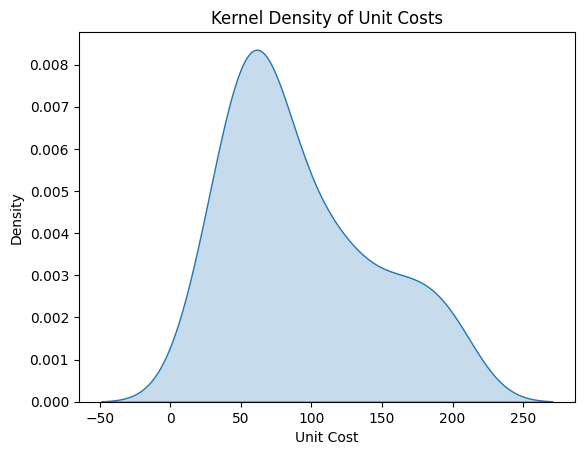

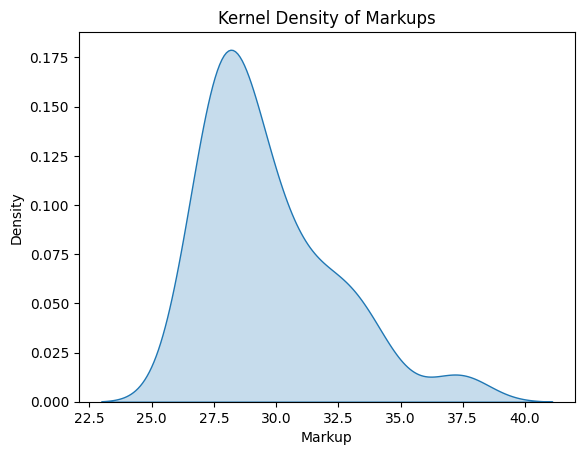

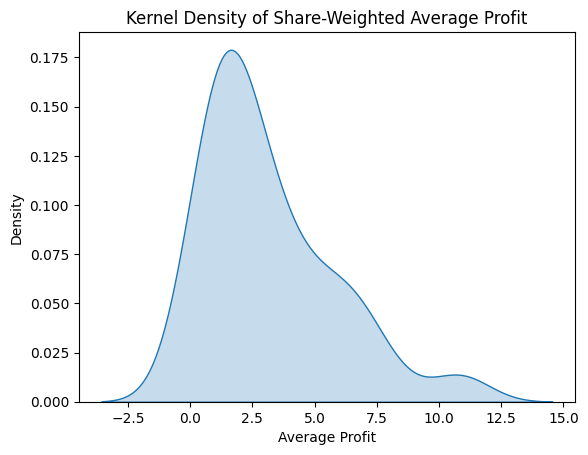

In [25]:
# unit cost
sns.kdeplot(data=results, x="unit_cost", fill=True)
plt.title("Kernel Density of Unit Costs")
plt.xlabel("Unit Cost")
plt.show()

# markup
sns.kdeplot(data=results, x="markup", fill=True)
plt.title("Kernel Density of Markups")
plt.xlabel("Markup")
plt.show()

# average profit
sns.kdeplot(data=results, x="average_profit", fill=True)
plt.title("Kernel Density of Share-Weighted Average Profit")
plt.xlabel("Average Profit")
plt.show()

7. **Make scatter plots of price vs. unit cost and average rating vs. unit cost.**

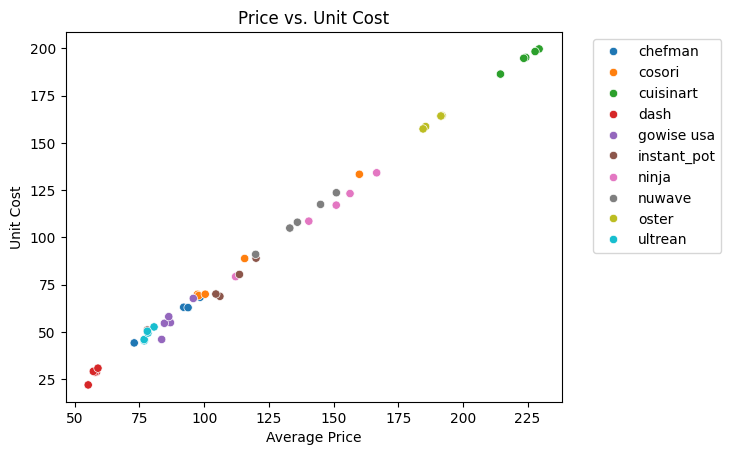

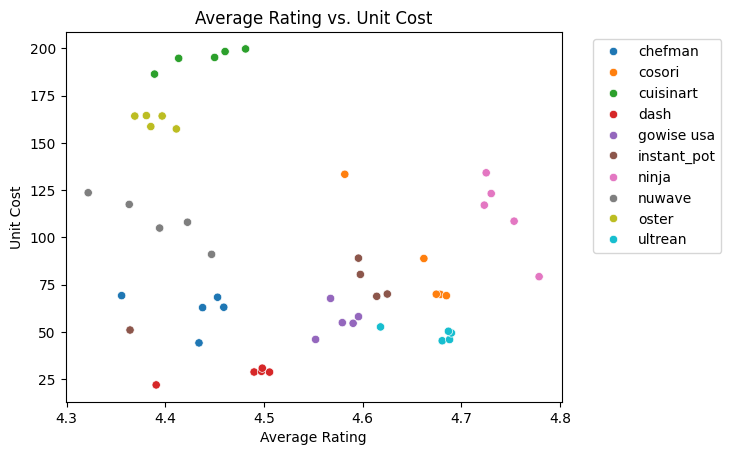

In [26]:
# price vs unit Cost
sns.scatterplot(data=results, x="avg_price", y="unit_cost", hue="brand")
plt.title("Price vs. Unit Cost")
plt.xlabel("Average Price")
plt.ylabel("Unit Cost")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

# rating vs unit Cost
sns.scatterplot(data=results, x="avg_rating", y="unit_cost", hue="brand")
plt.title("Average Rating vs. Unit Cost")
plt.xlabel("Average Rating")
plt.ylabel("Unit Cost")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

Finally, compute:

$$
\frac{d\pi_{bt}}{dp_{bt}} = \hat{s}'_{bt}(p_{bt})(p_{bt} - \hat{c}_{bt}) + s_{bt}.
$$

This should be very close to zero **by construction**, because you used the same first-order condition to estimate unit cost. Treat this as a numerical check, not as independent evidence that prices are truly optimal.

This part of the work is the **pricing analyst** or **applied economist** role: using a demand model to reason about price, cost, and profitability.

- I did this above when I found the profit derivative 
- All of my values were either zero or very close to zero 

## 4. Results

Submit a GitHub repo containing:

1. A short presentation of your findings, about 5-8 slides.
2. The code that created the tables and figures in your presentation.

Your presentation should be written as if you were giving market intelligence to a business audience. It should include:

- A short description of the air-fryer market
- A few plots showing prices, ratings, and market shares over time
- A short explanation of the demand model
- The estimated price coefficient and why its sign matters
- A discussion of the most important product features
- Estimated unit costs, markups, and share-weighted profits
- A conclusion: which brands look strongest, and what would you want to investigate next?

Do not fill slides with raw code. Use your code to produce clear tables and figures, then explain the market story in words.